In [16]:
import pandas as pd
import os
import json
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import cross_val_score, KFold

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from tqdm import tqdm

In [17]:
file_path = r"F:\\Project\\Global_AI_Impact\\processed_data\\encoded_ai_company_adoption.csv"
df = pd.read_csv(file_path)
meta_path = r"F:\\Project\\Global_AI_Impact\\processed_data\\meta_data.json"

In [18]:
with open(meta_path, "r", encoding="utf-8") as f:
    meta_data = json.load(f)
    
    NUMERIC_ORDINAL_COLS = meta_data["numeric_ordinal_cols"]
    ONEHOT_COLS = meta_data["onehot_cols"]
    CYCLIC_COLS = meta_data["cyclic_cols"]
    BINARY_COLS = meta_data["binary_cols"]

In [19]:
y = df['ai_failure_rate']
X = df.drop(columns=['ai_failure_rate'])
X.shape, y.shape

((150000, 87), (150000,))

In [20]:
# outcome_cols = [
#     'productivity_change_percent', 
#     'customer_satisfaction', 
#     'time_saved_per_week', 
#     'revenue_growth_percent', 
#     'cost_reduction_percent',
#     'jobs_displaced', 
#     'jobs_created', 
#     'reskilled_employees',
#     'employee_satisfaction_score',
#     'ai_maturity_score', 
#     'innovation_score',
#     'task_automation_rate'
# ]

# X = X.drop(columns=outcome_cols, errors='ignore')

# X.shape

Chuẩn hóa

In [21]:
def preprocess_data(X_train, X_test):
    valid_num_cols = [col for col in NUMERIC_ORDINAL_COLS if col in X_train.columns]
    valid_cat_cols = [col for col in ONEHOT_COLS if col in X_train.columns]
    valid_cyc_cols = [col for col in CYCLIC_COLS if col in X_train.columns]

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
    X_test_num = scaler.transform(X_test[valid_num_cols].astype(float))

    X_train_cat = X_train[valid_cat_cols].astype(float).values
    X_test_cat = X_test[valid_cat_cols].astype(float).values

    train_col_means = X_train_cat.mean(axis=0)
    train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)

    X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
    X_test_cat_scaled = X_test_cat / np.sqrt(train_col_means)

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values
    X_test_cyc = X_test[valid_cyc_cols].astype(float).values

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_test_combined = np.hstack([X_test_num, X_test_cat_scaled, X_test_cyc])

    return X_train_combined, X_test_combined

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

sample_size = 20000
X_train_sample = X_train_combined[:sample_size]
y_train_sample = y_train[:sample_size]

k_values = range(1, 201, 10)
cv_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in tqdm(k_values, desc="Tuning k"):
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sample, y_train_sample, cv=kf, scoring='r2')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"k tối ưu: {best_k}")
print(f"R2 max (trên tập mẫu): {max(cv_scores):.4f}")

Tuning k: 100%|██████████| 20/20 [00:25<00:00,  1.25s/it]

k tối ưu: 41
R2 max (trên tập mẫu): 0.4709


THỰC HIỆN TRÊN DỮ LIỆU GỐC

In [25]:
def run_knn_experiment_original(X_data, y_data, best_k):
    splits = [0.2, 0.3, 0.4] 
    results = []
    
    for test_size in tqdm(splits, desc="Running splits"):
        # Chia train/ test 
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)

        # Chuẩn hóa dữ liệu 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        # Mô hình
        model = KNeighborsRegressor(n_neighbors=best_k)
        model.fit(X_train_combined, y_train)
        
        y_train_pred = model.predict(X_train_combined)
        y_test_pred = model.predict(X_test_combined)

        # Đánh giá
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        split_label = f"{int((1-test_size)*10)}:{int(test_size*10)}"
        results.append({
            'Data Type': 'Original',
            'Split (Train:Test)': split_label,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Gap': train_r2 - test_r2,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train MSE': train_mse,
            'Test MSE': test_mse
        })
        
    return results

In [26]:
results_orig = run_knn_experiment_original(X, y, best_k)
df_orig = pd.DataFrame(results_orig)
display(df_orig)

Running splits: 100%|██████████| 3/3 [02:04<00:00, 41.58s/it]


,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Train MAE,Test MAE,Train MSE,Test MSE
0,Original,8:2,0.524792,0.501075,0.023717,4.314054,4.410183,28.659580,29.899436
1,Original,7:3,0.522067,0.500466,0.021601,4.326078,4.418966,28.831603,29.980305
2,Original,6:4,0.519724,0.496902,0.022822,4.335015,4.438942,28.946188,30.275270


THỰC HIỆN TRÊN DỮ LIỆU ĐÃ GIẢM CHIỀU

In [ ]:
def run_knn_experiment_pca(X_data, y_data, best_k):
    splits = [0.2, 0.3, 0.4] 
    results = []
    
    for test_size in tqdm(splits, desc="Running splits"):
        # Chia train/ test 
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)

        # Chuẩn hóa dữ liệu 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)
        
        # Áp dụng PCA
        pca = PCA(n_components=0.8)
        X_train_pca = pca.fit_transform(X_train_combined)
        X_test_pca = pca.transform(X_test_combined)
        print(f"Số thành phần PCA giữ lại: {X_train_pca.shape[1]}")
        print(f"Giải thích phương sai PCA: {pca.explained_variance_ratio_.sum():.4f}")
        
        # Mô hình dùng dữ liệu đã PCA
        model = KNeighborsRegressor(n_neighbors=best_k)
        model.fit(X_train_pca, y_train)
        
        y_train_pred = model.predict(X_train_pca)
        y_test_pred = model.predict(X_test_pca)

        # Đánh giá
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        split_label = f"{int((1-test_size)*10)}:{int(test_size*10)}"
        results.append({
            'Data Type': 'PCA',
            'Split (Train:Test)': split_label,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Gap': train_r2 - test_r2,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train MSE': train_mse,
            'Test MSE': test_mse
        })
        
    return results

In [28]:
results_pca = run_knn_experiment_pca(X, y, best_k)
df_pca = pd.DataFrame(results_pca)
display(df_pca)

Running splits:   0%|          | 0/3 [00:00<?, ?it/s]

Số thành phần PCA giữ lại: 46
Giải thích phương sai PCA: 0.8054


Running splits:  33%|███▎      | 1/3 [00:22<00:45, 22.94s/it]

Số thành phần PCA giữ lại: 46
Giải thích phương sai PCA: 0.8053


Running splits:  67%|██████▋   | 2/3 [00:43<00:21, 21.34s/it]

Số thành phần PCA giữ lại: 46
Giải thích phương sai PCA: 0.8054


Running splits: 100%|██████████| 3/3 [01:00<00:00, 20.22s/it]


,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Train MAE,Test MAE,Train MSE,Test MSE
0,PCA,8:2,0.513293,0.488915,0.024378,4.364705,4.462961,29.353072,30.628157
1,PCA,7:3,0.511859,0.488195,0.023663,4.371215,4.469675,29.447422,30.716772
2,PCA,6:4,0.510329,0.486772,0.023557,4.377465,4.481681,29.512369,30.884836


Số components cần để giữ 80% thông tin là: 47


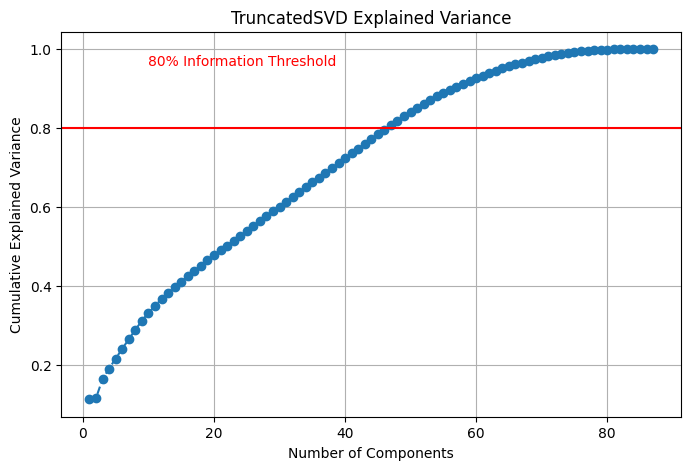

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_scaled, X_test_scaled = preprocess_data(X_train, X_test)
svd_test = TruncatedSVD(n_components=87, random_state=42)
svd_test.fit(X_train_scaled)

cumulative_variance = np.cumsum(svd_test.explained_variance_ratio_)

n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
print(f"Số components cần để giữ 80% thông tin là: {n_components_80}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 88), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.8, color='r', linestyle='-')
plt.text(10, 0.96, '80% Information Threshold', color = 'red')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('TruncatedSVD Explained Variance')
plt.grid(True)
plt.show()

In [31]:
def run_knn_experiment_svd(X_data, y_data, best_k, n_components=47):
    splits = [0.2, 0.3, 0.4] 
    results = []
    
    for test_size in tqdm(splits, desc="Running splits"):
        # Chia train/ test 
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)

        # Chuẩn hóa dữ liệu 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)
        
        # Áp dụng TruncatedSVD
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        X_train_svd = svd.fit_transform(X_train_combined)
        X_test_svd = svd.transform(X_test_combined)

        # Mô hình 
        model = KNeighborsRegressor(n_neighbors=best_k)
        model.fit(X_train_svd, y_train)
        
        y_train_pred = model.predict(X_train_svd)
        y_test_pred = model.predict(X_test_svd)

        # Đánh giá
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        split_label = f"{int((1-test_size)*10)}:{int(test_size*10)}"
        results.append({
            'Data Type': 'TruncatedSVD',
            'Split (Train:Test)': split_label,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Gap': train_r2 - test_r2,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train MSE': train_mse,
            'Test MSE': test_mse
        })
        
    return results

In [32]:
results_svd = run_knn_experiment_svd(X, y, best_k)
df_svd = pd.DataFrame(results_svd)
display(df_svd)

Running splits: 100%|██████████| 3/3 [01:12<00:00, 24.13s/it]


,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Train MAE,Test MAE,Train MSE,Test MSE
0,TruncatedSVD,8:2,0.512814,0.487929,0.024884,4.367848,4.467472,29.381953,30.687223
1,TruncatedSVD,7:3,0.511498,0.487765,0.023733,4.373285,4.472650,29.469205,30.742597
2,TruncatedSVD,6:4,0.509692,0.486164,0.023528,4.379444,4.483671,29.550783,30.921455


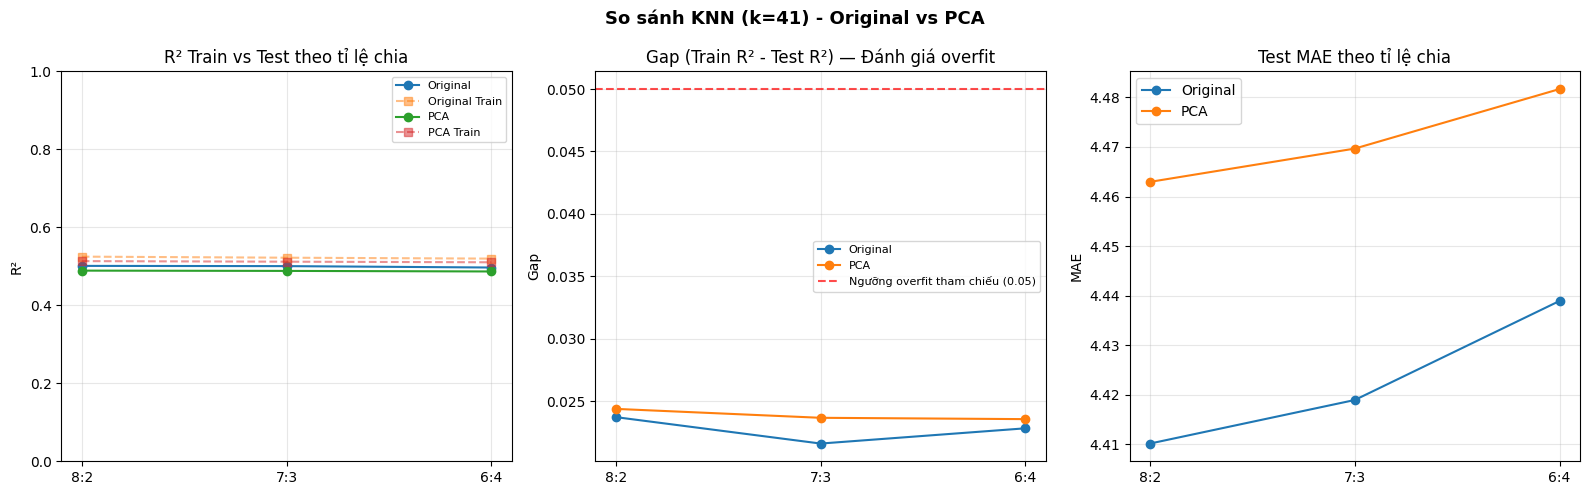

,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Test MAE
0,Original,8:2,0.5248,0.5011,0.0237,4.4102
1,Original,7:3,0.5221,0.5005,0.0216,4.4190
2,Original,6:4,0.5197,0.4969,0.0228,4.4389
3,PCA,8:2,0.5133,0.4889,0.0244,4.4630
4,PCA,7:3,0.5119,0.4882,0.0237,4.4697
5,PCA,6:4,0.5103,0.4868,0.0236,4.4817


In [33]:
df_all = pd.concat([df_orig, df_pca], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits_order = ['8:2', '7:3', '6:4']

#Test R2
for dtype, grp in df_all.groupby('Data Type'):
    grp = grp.set_index('Split (Train:Test)').loc[splits_order]
    axes[0].plot(splits_order, grp['Test R2'], marker='o', label=dtype)
    axes[0].plot(splits_order, grp['Train R2'], marker='s', linestyle='--', alpha=0.5, label=f'{dtype} Train')
axes[0].set_title('R² Train vs Test theo tỉ lệ chia')
axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

#Gap (Train R2 - Test R2)
for dtype, grp in df_all.groupby('Data Type'):
    grp = grp.set_index('Split (Train:Test)').loc[splits_order]
    axes[1].plot(splits_order, grp['Gap'], marker='o', label=dtype)
axes[1].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Ngưỡng overfit tham chiếu (0.05)')
axes[1].set_title('Gap (Train R² - Test R²) — Đánh giá overfit')
axes[1].set_ylabel('Gap')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

#Test MAE
for dtype, grp in df_all.groupby('Data Type'):
    grp = grp.set_index('Split (Train:Test)').loc[splits_order]
    axes[2].plot(splits_order, grp['Test MAE'], marker='o', label=dtype)
axes[2].set_title('Test MAE theo tỉ lệ chia')
axes[2].set_ylabel('MAE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'So sánh KNN (k={best_k}) - Original vs PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(df_all[['Data Type','Split (Train:Test)','Train R2','Test R2','Gap','Test MAE']].round(4))

Analyzing overfit across k: 100%|██████████| 11/11 [00:10<00:00,  1.07it/s]


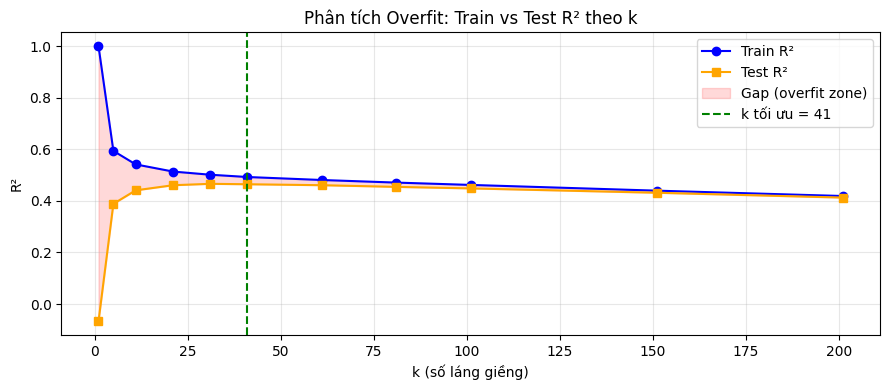


Gap tại k=41: Train R² - Test R² = 0.4925 - 0.4644 = 0.0281


In [34]:
#Phân tích overfit
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)
X_tr, X_te = preprocess_data(X_train_70, X_test_30)

k_range = [1, 5, 11, 21, 31, 41, 61, 81, 101, 151, 201]
train_r2_list, test_r2_list = [], []

SAMPLE = 15000
X_tr_s, y_tr_s = X_tr[:SAMPLE], y_train_70.values[:SAMPLE]
X_te_s, y_te_s = X_te[:SAMPLE], y_test_30.values[:SAMPLE]

for k in tqdm(k_range, desc="Analyzing overfit across k"):
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_tr_s, y_tr_s)
    train_r2_list.append(r2_score(y_tr_s, m.predict(X_tr_s)))
    test_r2_list.append(r2_score(y_te_s, m.predict(X_te_s)))

plt.figure(figsize=(9, 4))
plt.plot(k_range, train_r2_list, marker='o', label='Train R²', color='blue')
plt.plot(k_range, test_r2_list, marker='s', label='Test R²', color='orange')
plt.fill_between(k_range, train_r2_list, test_r2_list, alpha=0.15, color='red', label='Gap (overfit zone)')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'k tối ưu = {best_k}')
plt.xlabel('k (số láng giềng)')
plt.ylabel('R²')
plt.title('Phân tích Overfit: Train vs Test R² theo k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGap tại k={best_k}: Train R² - Test R² = {train_r2_list[k_range.index(best_k)]:.4f} - {test_r2_list[k_range.index(best_k)]:.4f} = {train_r2_list[k_range.index(best_k)] - test_r2_list[k_range.index(best_k)]:.4f}")

Evaluating regularization configs: 100%|██████████| 5/5 [02:53<00:00, 34.61s/it]


,Cấu hình,Train R²,Test R²,Gap,Test MAE
0,KNN uniform (k=41),0.5221,0.5005,0.0216,4.4190
1,KNN distance-weighted (k=41),1.0000,0.5017,0.4983,4.4131
2,KNN + PCA uniform (k=41),0.5182,0.4963,0.0219,4.4380
3,KNN + PCA distance-weighted (k=41),1.0000,0.4976,0.5024,4.4321
4,KNN uniform (k=82),0.5072,0.4963,0.0109,4.4387


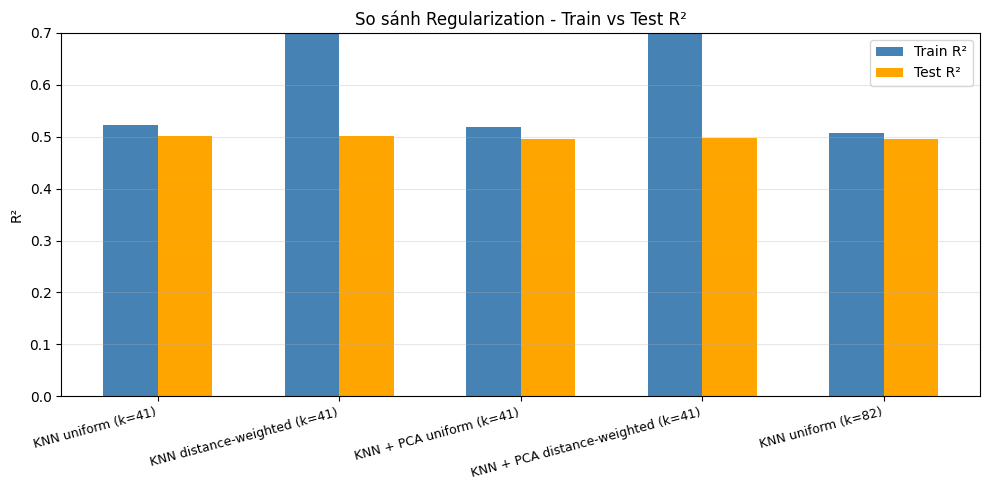

In [36]:
#3 dạng regularization cho KNN
#Tăng k (như trên)
#Dùng trọng số distance (weights='distance')
#Kết hợp PCA + weights='distance'

X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)
X_tr, X_te = preprocess_data(X_train_70, X_test_30)

regularization_results = []

configs = [
    {'name': f'KNN uniform (k={best_k})', 'k': best_k, 'weights': 'uniform', 'use_pca': False},
    {'name': f'KNN distance-weighted (k={best_k})', 'k': best_k, 'weights': 'distance', 'use_pca': False},
    {'name': f'KNN + PCA uniform (k={best_k})', 'k': best_k, 'weights': 'uniform', 'use_pca': True},
    {'name': f'KNN + PCA distance-weighted (k={best_k})', 'k': best_k, 'weights': 'distance', 'use_pca': True},
    {'name': f'KNN uniform (k={best_k*2})', 'k': best_k * 2, 'weights': 'uniform', 'use_pca': False},
]

for cfg in tqdm(configs, desc="Evaluating regularization configs"):
    if cfg['use_pca']:
        pca = PCA(n_components=0.95)
        X_tr_in = pca.fit_transform(X_tr)
        X_te_in = pca.transform(X_te)
    else:
        X_tr_in, X_te_in = X_tr, X_te
    
    model = KNeighborsRegressor(n_neighbors=cfg['k'], weights=cfg['weights'])
    model.fit(X_tr_in, y_train_70)
    
    train_r2 = r2_score(y_train_70, model.predict(X_tr_in))
    test_r2  = r2_score(y_test_30, model.predict(X_te_in))
    
    regularization_results.append({
        'Cấu hình': cfg['name'],
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'Gap': round(train_r2 - test_r2, 4),
        'Test MAE': round(mean_absolute_error(y_test_30, model.predict(X_te_in)), 4)
    })

df_reg = pd.DataFrame(regularization_results)
display(df_reg)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_reg))
width = 0.3
ax.bar(x - width/2, df_reg['Train R²'], width, label='Train R²', color='steelblue')
ax.bar(x + width/2, df_reg['Test R²'], width, label='Test R²', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(df_reg['Cấu hình'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('So sánh Regularization - Train vs Test R²')
ax.legend()
ax.set_ylim(0, 0.7)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

TRỰC QUAN HÓA VÀ ĐÁNH GIÁ TƯƠNG QUAN GIỮA PHẦN VÀ BẢN THÂN ĐẦU VÀO

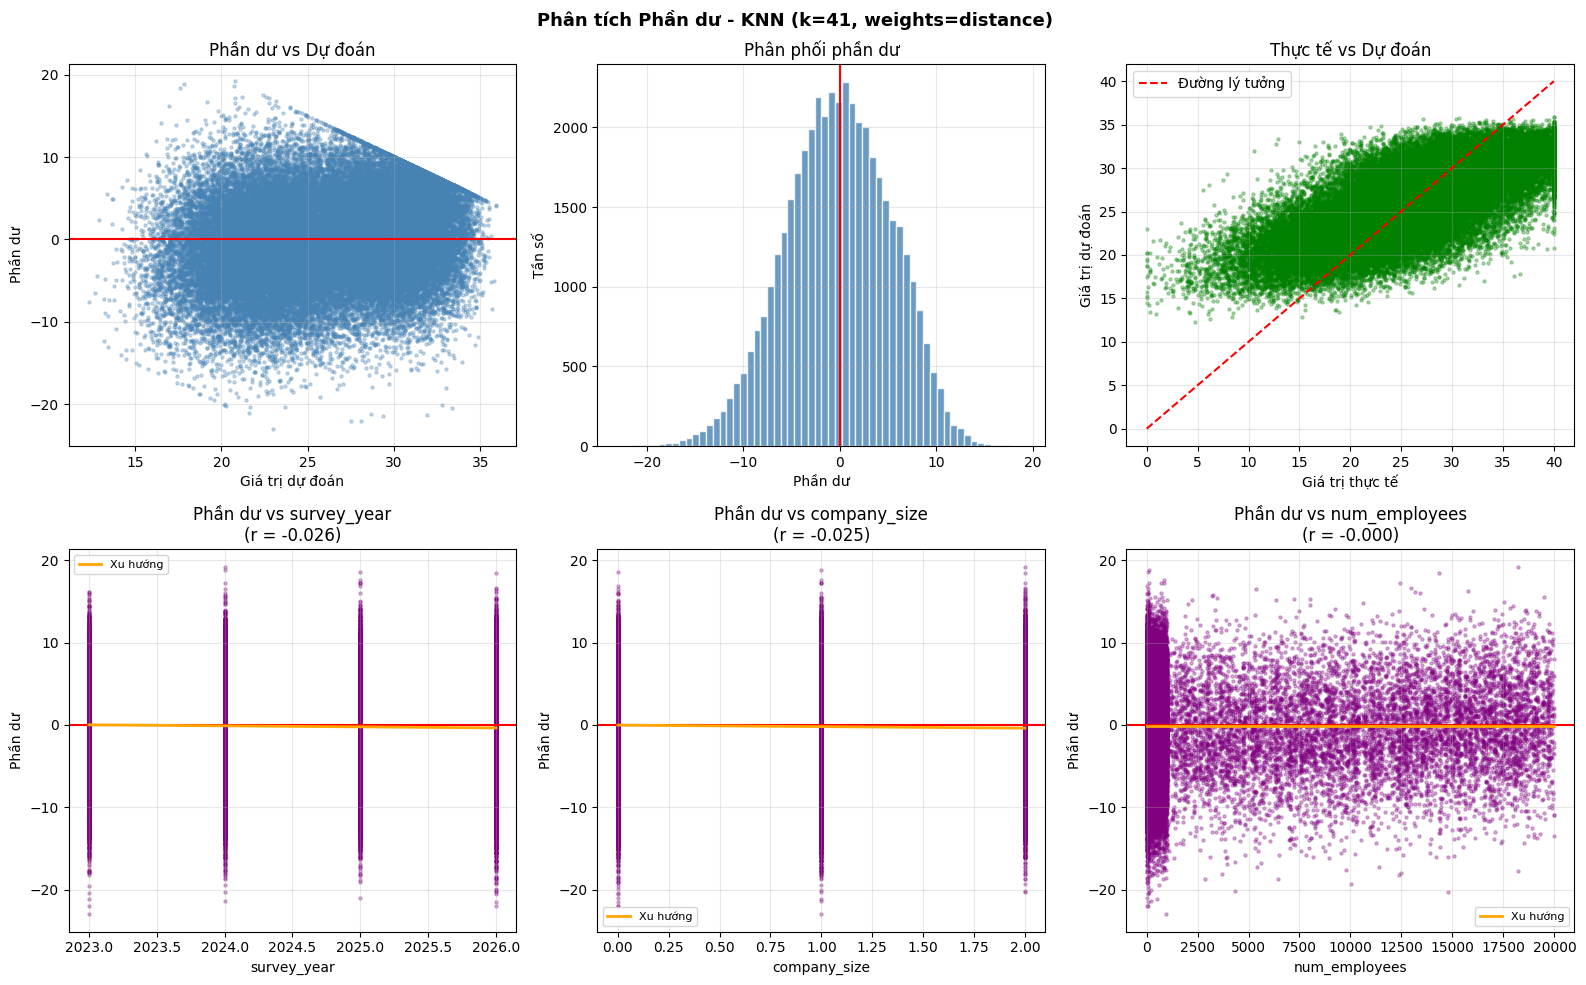

  Mean:   -0.1763
  Std:    5.4658
  Min:    -22.9914
  Max:    19.2091


In [37]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X, y, test_size=0.3, random_state=42)
X_tr_f, X_te_f = preprocess_data(X_train_f, X_test_f)

final_model = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
final_model.fit(X_tr_f, y_train_f)

y_pred_test = final_model.predict(X_te_f)
residuals = y_test_f.values - y_pred_test

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# 1. Residuals vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
ax1.axhline(0, color='red', linewidth=1.5)
ax1.set_xlabel('Giá trị dự đoán')
ax1.set_ylabel('Phần dư')
ax1.set_title('Phần dư vs Dự đoán')
ax1.grid(True, alpha=0.3)

# 2. Phân phối phần dư
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linewidth=1.5)
ax2.set_xlabel('Phần dư')
ax2.set_ylabel('Tần số')
ax2.set_title('Phân phối phần dư')
ax2.grid(True, alpha=0.3)

# 3. Actual vs Predicted
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(y_test_f.values, y_pred_test, alpha=0.3, s=5, color='green')
mn, mx = y_test_f.min(), y_test_f.max()
ax3.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Đường lý tưởng')
ax3.set_xlabel('Giá trị thực tế')
ax3.set_ylabel('Giá trị dự đoán')
ax3.set_title('Thực tế vs Dự đoán')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4-6. Phần dư vs 3 biến đầu vào 
num_input_cols = [c for c in NUMERIC_ORDINAL_COLS if c in X_test_f.columns][:3]

for idx, col in enumerate(num_input_cols):
    ax = fig.add_subplot(gs[1, idx])
    col_vals = X_test_f[col].values
    ax.scatter(col_vals, residuals, alpha=0.3, s=5, color='purple')
    ax.axhline(0, color='red', linewidth=1.5)
    
    z = np.polyfit(col_vals, residuals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(col_vals.min(), col_vals.max(), 200)
    ax.plot(x_line, p(x_line), 'orange', linewidth=2, label='Xu hướng')
    
    corr = np.corrcoef(col_vals, residuals)[0, 1]
    ax.set_xlabel(col)
    ax.set_ylabel('Phần dư')
    ax.set_title(f'Phần dư vs {col}\n(r = {corr:.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Phân tích Phần dư - KNN (k={best_k}, weights=distance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"  Mean:   {residuals.mean():.4f}")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Min:    {residuals.min():.4f}")
print(f"  Max:    {residuals.max():.4f}")

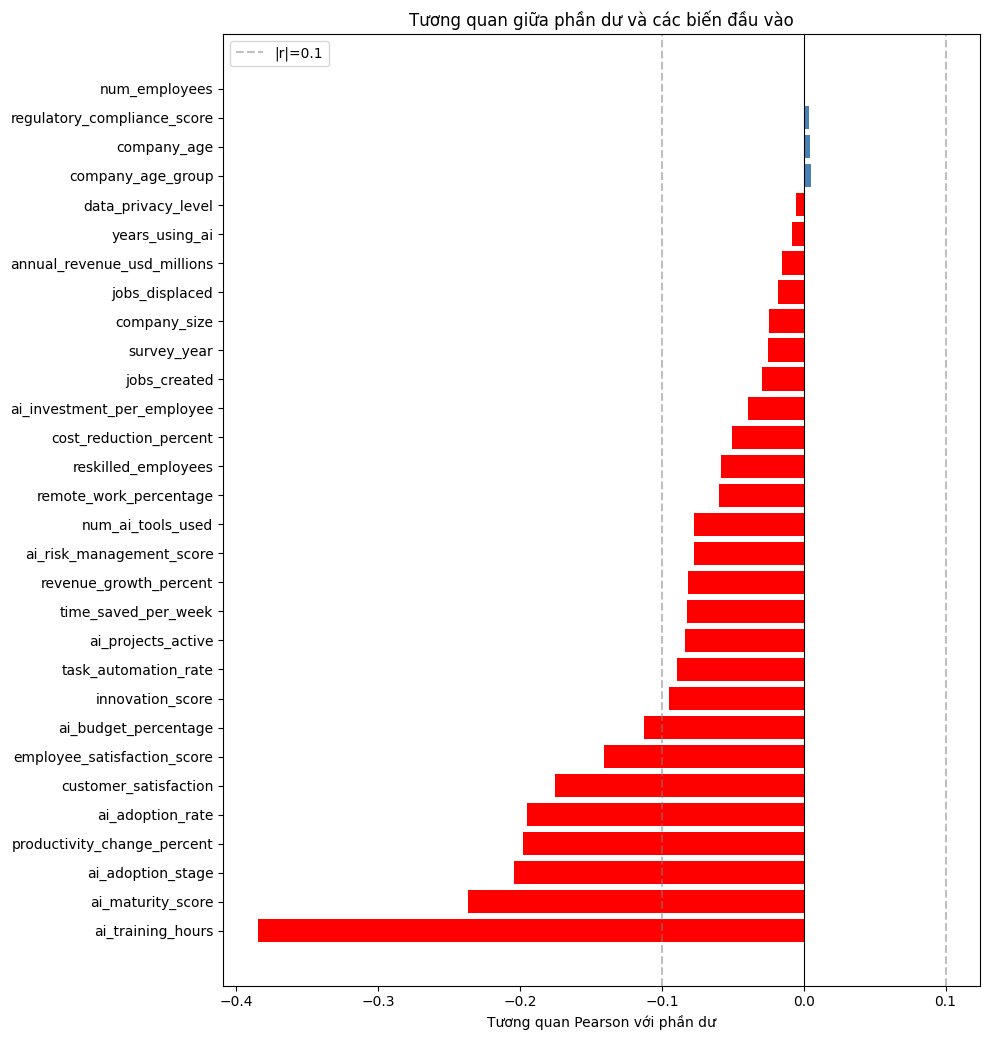


5 biến có tương quan cao nhất với phần dư:
ai_training_hours             -0.385065
ai_maturity_score             -0.236462
ai_adoption_stage             -0.204515
productivity_change_percent   -0.198200
ai_adoption_rate              -0.195292


In [38]:
# Tương quan phần dư với TẤT CẢ các biến đầu vào số
num_cols_available = [c for c in NUMERIC_ORDINAL_COLS if c in X_test_f.columns]
corr_dict = {}
for col in num_cols_available:
    corr_dict[col] = np.corrcoef(X_test_f[col].values, residuals)[0, 1]

corr_series = pd.Series(corr_dict).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, max(4, len(corr_series) * 0.35)))
colors = ['red' if v < 0 else 'steelblue' for v in corr_series.values]
plt.barh(corr_series.index, corr_series.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='|r|=0.1')
plt.axvline(-0.1, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Tương quan Pearson với phần dư')
plt.title('Tương quan giữa phần dư và các biến đầu vào')
plt.legend()
plt.tight_layout()
plt.show()

print("\n5 biến có tương quan cao nhất với phần dư:")
print(corr_series.head(5).to_string())

In [39]:
def run_linear_regression(X_train, X_test, y_train, y_test, scale=True):
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler
    import numpy as np
    
    # Scale (khuyến nghị nên bật)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Residual
    residuals = y_test - y_pred
    
    print("=== Linear Regression Results ===")
    print(f"MSE: {mse:.4f}")
    print(f"R2 : {r2:.4f}")
    print(f"Mean residual: {np.mean(residuals):.4f}")
    
    return model, y_pred, residuals

In [40]:
def plot_residual_distribution(residuals):
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=30)
    plt.title("Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()

In [41]:
def plot_residuals(y_pred, residuals):
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()

=== Linear Regression Results ===
MSE: 23.4369
R2 : 0.6095
Mean residual: 0.0023


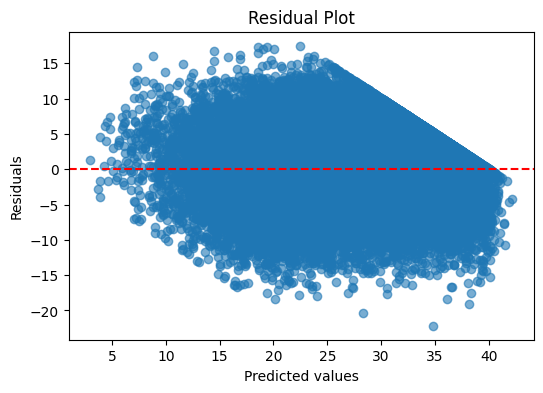

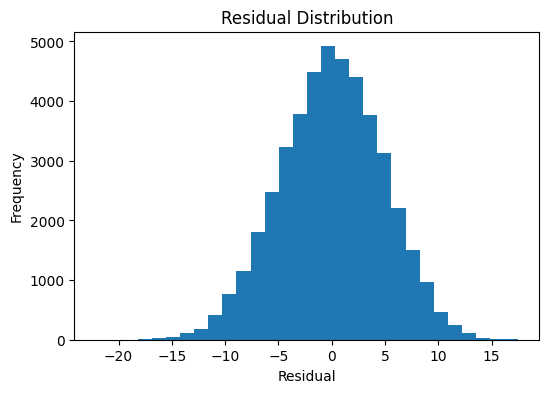

In [42]:
model, y_pred, residuals = run_linear_regression(
    X_train, X_test, y_train, y_test
)

plot_residuals(y_pred, residuals)
plot_residual_distribution(residuals)

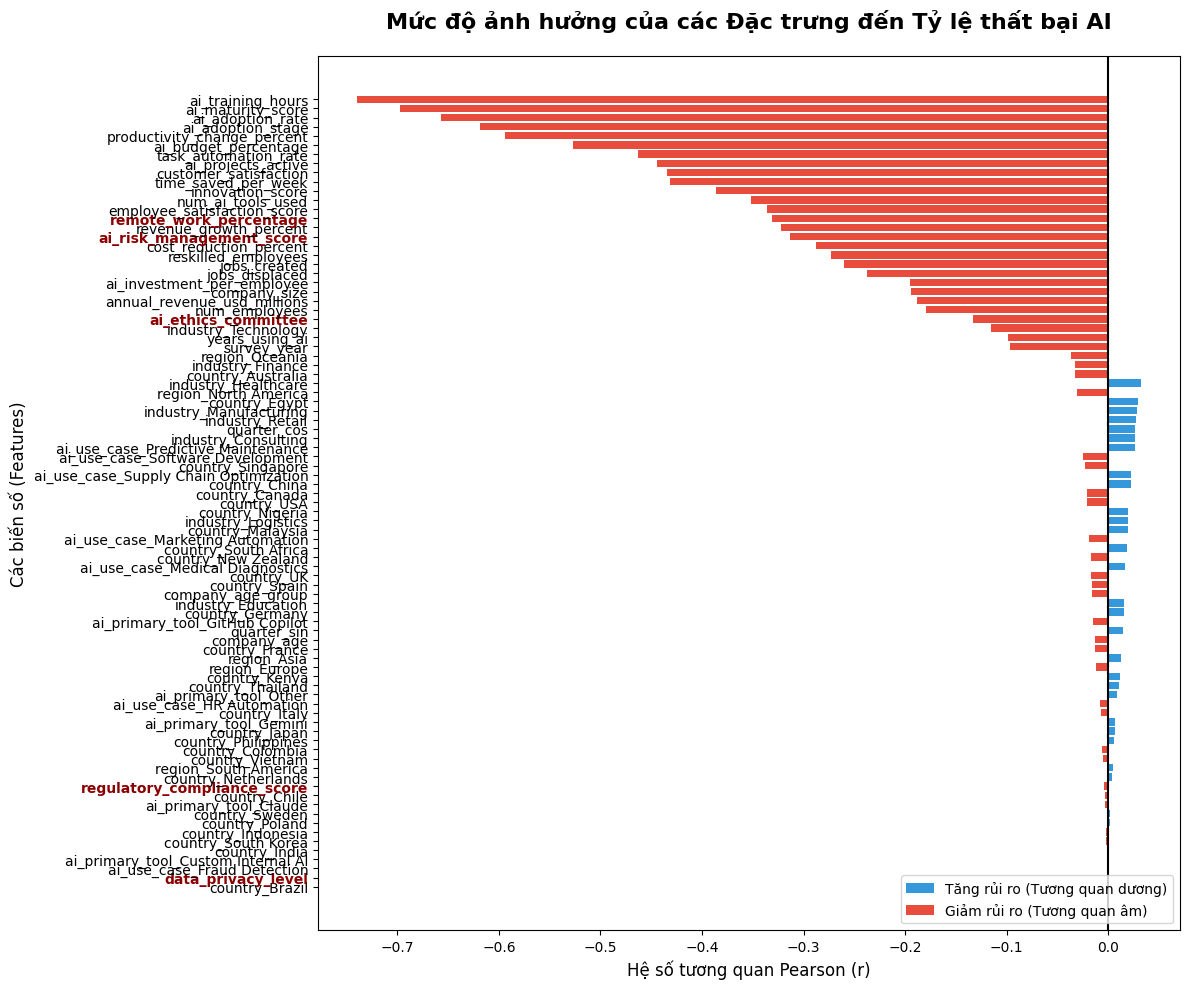

In [43]:
correlations = X.corrwith(y)
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=True).index)
plt.figure(figsize=(12, 10))

# Phân màu: 
# Màu xanh (Positive) -> Làm TĂNG tỷ lệ thất bại (Rủi ro)
# Màu đỏ (Negative)  -> Làm GIẢM tỷ lệ thất bại (Phòng vệ)
colors = ['#e74c3c' if val < 0 else '#3498db' for val in correlations_sorted.values]

plt.barh(correlations_sorted.index, correlations_sorted.values, color=colors)

# Thêm đường tham chiếu ở mốc 0
plt.axvline(0, color='black', linewidth=1.5)

# Thiết lập nhãn và tiêu đề
plt.title('Mức độ ảnh hưởng của các Đặc trưng đến Tỷ lệ thất bại AI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hệ số tương quan Pearson (r)', fontsize=12)
plt.ylabel('Các biến số (Features)', fontsize=12)

# 4. Tùy chỉnh đặc biệt cho Báo cáo: Tô đậm các biến Quản trị (Governance)
# Cập nhật danh sách này theo các biến quản trị bạn đang có trong X
gov_cols = [
    'ai_ethics_committee', 
    'data_privacy_level', 
    'regulatory_compliance_score', 
    'ai_risk_management_score',
    'remote_work_percentage'
]

ax = plt.gca()
for label in ax.get_yticklabels():
    if label.get_text() in gov_cols:
        label.set_color('darkred')       # Đổi màu chữ thành đỏ đậm
        label.set_fontweight('bold')     # In đậm để thu hút sự chú ý của người đọc

# Thêm chú thích (Legend) tùy chỉnh
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Tăng rủi ro (Tương quan dương)'),
    Patch(facecolor='#e74c3c', label='Giảm rủi ro (Tương quan âm)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()